In [3]:
import pandas as pd
url = 'https://raw.githubusercontent.com/pia222sk20/python/refs/heads/main/data/movies_train.csv'
df = pd.read_csv(url)
df.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [4]:
# 결측치

In [5]:
# 강사님 풀이
# 미싱노로 확인
# 결측치 비율 확인
# 결측치가 있는 감독을 파악, 왜냐하면 결측치가 있는 컬럼이 이전에 낸 영화 갯수이기 때문
# 잘못 채워진 데이터가 아니라 제대로 표기를 했지만 그걸 nan으로 표시한 걸수도있기 때문

In [6]:
# 학생 풀이 1트
# df.info()
# 일단 바로보이는 건 dir_prev_bfnum
# 다른 것중에 직관적으로 보이는 결측치는 안보이고, object항목에서도 결측치가 예상이 될만한 것이 딱히 안보임
# 인공지능 검토 사용 해봄

# NaN 값을 해당 컬럼에 타입 으로 변환?
# print(type(df['dir_prev_bfnum'][0]))
# <class 'numpy.float64'>
# 넘파이 실수형태
# nan을 넘파이 실수형태 0으로 변환
# df['dir_prev_bfnum'] = df['dir_prev_bfnum'].fillna(0)
# df['dir_prev_bfnum']

In [7]:
# 결측치가 있는 데이터의 감독은?
# 결측치 주변 데이터 를 확인
# 결측치가 생긴 원인 파악 - 이전 영화가 없는 감독이면 ... 정상적인 데이터

In [8]:
df[df['dir_prev_bfnum'].isna()]

# df['director'] == '조병옥' 로 True, False 변환
df[df['director'] == '조병옥']

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398


In [20]:
df['dir_prev_bfnum'] = df['dir_prev_bfnum'].fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    object 
 1   distributor     600 non-null    object 
 2   genre           600 non-null    object 
 3   release_time    600 non-null    object 
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    object 
 6   director        600 non-null    object 
 7   dir_prev_bfnum  600 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 56.4+ KB


In [10]:
df.describe()

,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
count,600.000000,6.000000e+02,600.000000,600.000000,600.000000,6.000000e+02
mean,100.863333,4.726993e+05,0.876667,151.118333,3.706667,7.081818e+05
std,18.097528,1.309474e+06,1.183409,165.654671,2.446889,1.828006e+06
min,45.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
25%,89.000000,0.000000e+00,0.000000,17.000000,2.000000,1.297250e+03
50%,100.000000,0.000000e+00,0.000000,82.500000,3.000000,1.259100e+04
75%,114.000000,3.761416e+05,2.000000,264.000000,4.000000,4.798868e+05
max,180.000000,1.761531e+07,5.000000,869.000000,25.000000,1.426277e+07


100000.0


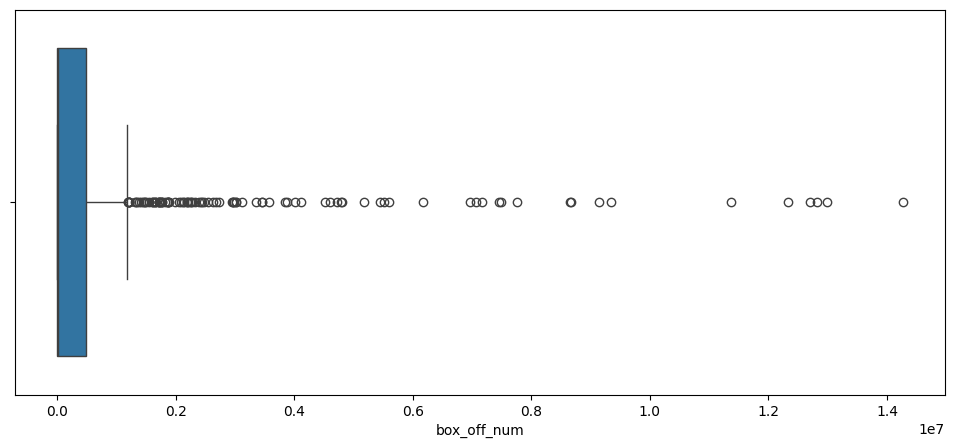

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
sns.boxplot(data=df,x='box_off_num')
print(0.1 * 1000000)

<Axes: >

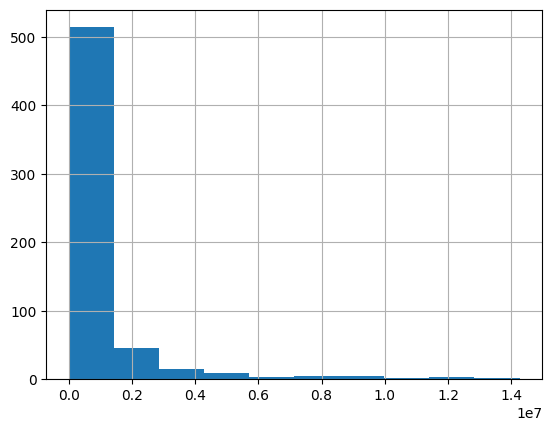

In [12]:
df.box_off_num.hist()

In [13]:

# 데이터 분포특성
# 왼쪽으로 치우쳐져서 오른쪽 꼬리가 긴 형태(대부분의 관객수는 5만명대에 형성되어 있고)
#  outlier가 많고 크다 즉.. 히트작의 영향이 크다

In [14]:
df.describe() 
# 수치계산이 되는 애들만 조회하기도 한거구나

,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
count,600.000000,6.000000e+02,600.000000,600.000000,600.000000,6.000000e+02
mean,100.863333,4.726993e+05,0.876667,151.118333,3.706667,7.081818e+05
std,18.097528,1.309474e+06,1.183409,165.654671,2.446889,1.828006e+06
min,45.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
25%,89.000000,0.000000e+00,0.000000,17.000000,2.000000,1.297250e+03
50%,100.000000,0.000000e+00,0.000000,82.500000,3.000000,1.259100e+04
75%,114.000000,3.761416e+05,2.000000,264.000000,4.000000,4.798868e+05
max,180.000000,1.761531e+07,5.000000,869.000000,25.000000,1.426277e+07


In [15]:
# 관객수 box_off_num 과 높은 상관관계를 가지는 변수 찾기

In [ ]:
# 학생 풀이 1트
# 관객수 box_off_num 과 높은 상관관계를 가지는 변수 찾기
# 상관계수 구하는 수식
# corr_xy = df['x'].corr(df['y'])

corr_b_t = df['box_off_num'].corr(df['time'],method='spearman')
corr_b_d_bp = df['box_off_num'].corr(df['dir_prev_bfnum'],method='spearman')
corr_b_d_p = df['box_off_num'].corr(df['dir_prev_num'],method='spearman')
corr_b_s = df['box_off_num'].corr(df['num_staff'],method='spearman')
corr_b_a = df['box_off_num'].corr(df['num_actor'],method='spearman')
# method='spearman' ^ 이걸 사용한이유 이상치가 많기때문에 그거에 덜 영향이 받는 걸로 설정 ^
print(f'관객수 상관계수\n시간 : {corr_b_t}\n감독의 이전 작품 갯수 : {corr_b_d_bp}\n감독의 이전 작품 박스오피스 성적 : {corr_b_d_p}\n제작진 : {corr_b_s}\n배우 : {corr_b_a}')

관객수 상관계수
시간 : 0.4414523915408284
감독의 이전 작품 갯수 : 0.29379081441824567
감독의 이전 작품 박스오피스 성적 : 0.2596738577785138
제작진 : 0.5442647163889157
배우 : 0.1111793445038867


<Axes: >

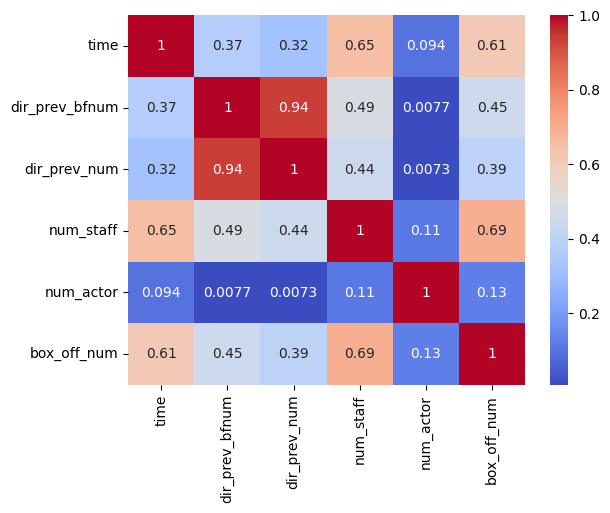

In [22]:
# 강사님 풀이
# 관객수  box_off_num과 높은 상관관계를 가지는 변수를 
corr = df.corr(method='spearman',numeric_only=True)
sns.heatmap(corr, annot=True,cmap='coolwarm')

In [18]:
# 관객수는 상영시간과 스텝수 높은 상관관계 - 상영시간이 갈수록 관객수가 증가하는 경향

In [24]:
df.describe(include=['object','category'])

,title,distributor,genre,release_time,screening_rat,director
count,600,600,600,600,600,600
unique,600,169,12,330,4,472
top,개들의 전쟁,CJ 엔터테인먼트,드라마,2010-09-16,청소년 관람불가,홍상수
freq,1,54,221,6,204,7


# 범주형 변수 분석

In [27]:
df.describe(include=['object','category'])

,title,distributor,genre,release_time,screening_rat,director
count,600,600,600,600,600,600
unique,600,169,12,330,4,472
top,개들의 전쟁,CJ 엔터테인먼트,드라마,2010-09-16,청소년 관람불가,홍상수
freq,1,54,221,6,204,7


피어슨 상관계수
```
상관계수는 두변수 간의 관계 강도와 방향을 측정
피어슨 상관계수 : 선형관계를 측정, 데이터가 정규분포 따르고 선형일때
스피어만 : 순위기반, 비선형관계나 또는 순서데이터(예 : 순위, 크기)
```
![피어슨 상관계수.png](<attachment:피어슨 상관계수.png>)
```
피어슨 상관계수
두변수 x,y의 공분산을 각 변수의 표준편차로 나눈 값
1. 각 변수의 평균 계산
2. 각 데이터 포인트에서 평균을 뺀 값을 계산
3. 편차들 곱 합 계산(공분산 분자 계산)
4. 각편차 제곱합 계산
5. 분자 / (분모의 제곱근)으로 계산
```

데이터가 연속적이고 선형적일때 사용

시그마는
음수를 없애기 위해서 제곱을 한다.
# https://chatgpt.com/s/t_68de34866e448191b23ac04ac2e681f2

평균을 다루는 데 영향을 받는게 이상치 그래서..
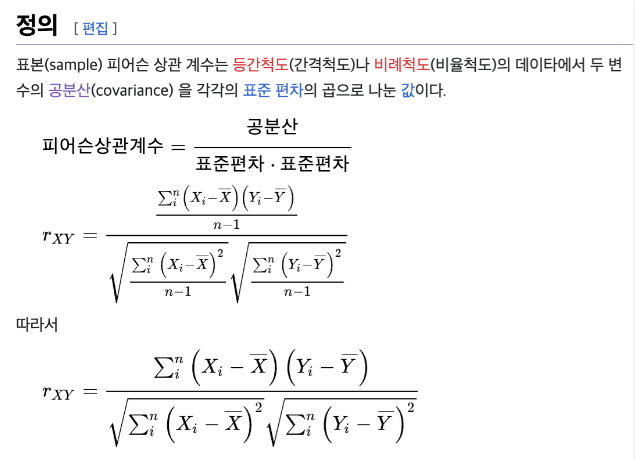

스피어만 상관계수
```
두변수의 순위(rank)를 변환한 후 적용 - 실제 데이터 값 대신에 순위를 사용
```
![스피어만 상관계수.jpg](<attachment:스피어만 상관계수.jpg>)
```
1. 각 변수의 x와 y의 데이터를 오름차순(낮은 수부터 배열)으로 정렬해 순위 부여(동점 평균순위 사용)
2. 각 데이터 쌍의 순위 차이(di = rankx - ranky)
3. di^2(음수 제거) 합을 계산
4. 1 - (di^2 합 계산 / n(n^2-1))
```

이상치나 비선형 관계에 적합
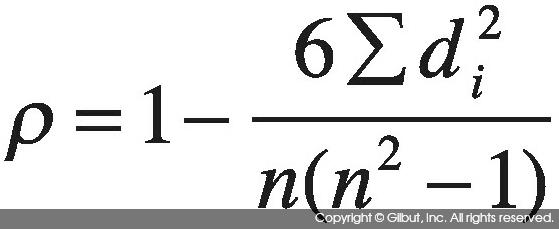

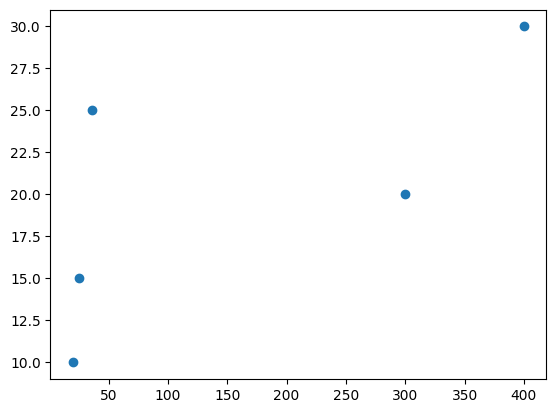

In [12]:
# x(온도) y(이스크림 판매량)
import numpy as np
import matplotlib.pyplot as plt
# x = np.array([20,25,30,36,40])
# y = np.array([10,15,20,25,30])

# x(온도) y(이스크림 판매량) 이상치 부여
x = np.array([20,25,300,36,400])
y = np.array([10,15,20,25,30])

x_mean = x.mean()
y_mean = y.mean()

# x y 편차
x_ = x - x_mean
y_ = y - y_mean

# 분자 : 편차의 곱 합
(x_ * y_).sum()

# x 편차, y 편차의 각각 제곱의 합
(x_**2).sum() , (y_**2).sum()

(x_**2).sum()*(y_**2).sum()

# 분모
np.sqrt((x_**2).sum()*(y_**2).sum())

(x_ * y_).sum() / np.sqrt((x_**2).sum()*(y_**2).sum())

plt.scatter(x,y)

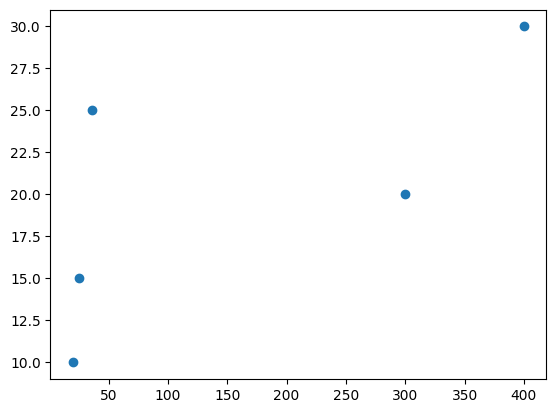

In [13]:
# 스피어만 상관계수
import numpy as np
# x = np.array([20,25,30,36,40])
# y = np.array([10,15,20,25,30])

# x(온도) y(이스크림 판매량) 이상치 부여
x = np.array([20,25,300,36,400])
y = np.array([10,15,20,25,30])

rank_x = [1,2,3,4,5]
rank_y = [1,2,3,4,5]

# 순위차이
di = [0,0,0,0,0] # 모두 동일 순위
# 분자 0 
# 1 - (0 / 5 (25-1))
1 - (0 / 5*(25-1))

plt.scatter(x,y)